<a href="https://colab.research.google.com/github/chaudhary-hadi27/Hands-On-ML-with-SK-Learn-Keras-and-TF/blob/main/part1/chapter_02/lets_dirty_your_hand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform data cleaning and exploratory data analysis on the "House_Price_Prediction_Dataset.csv" dataset, handling missing and duplicate values, identifying and dropping unnecessary columns, and providing insights from EDA, to prepare a cleaned dataset.

## Load Dataset

### Subtask:
Load the 'House_Price_Prediction_Dataset.csv' file into a pandas DataFrame.


**Reasoning**:
To load the dataset, I need to import the pandas library and then use its `read_csv` function. Displaying the head of the DataFrame will confirm successful loading.



In [1]:
import pandas as pd
df = pd.read_csv('House_Price_Prediction_Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Initial Data Inspection

### Subtask:
Display the first few rows, data types, and a summary of the dataset to understand its structure and identify potential issues.


**Reasoning**:
To understand the dataset's structure, identify data types, and get a statistical summary, I will display the first few rows, information about the columns (including data types and non-null counts), and descriptive statistics for numerical columns.



In [2]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

First 5 rows of the DataFrame:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Handle Missing Values

### Subtask:
Identify and handle any missing values in the dataset. This might involve imputation, dropping rows/columns, or other appropriate strategies based on the nature of the missing data.


**Reasoning**:
To identify any missing values, I will use `.isnull().sum()` to get a count of missing values per column and then `.isnull().sum().sum()` to get the total number of missing values in the entire DataFrame.



In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

Missing values per column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Total missing values in the dataset:
0


## Handle Duplicate Values

### Subtask:
Check for and remove any duplicate rows in the dataset to ensure data integrity.


**Reasoning**:
To identify and handle duplicate rows, I will first calculate the number of duplicate rows using `duplicated().sum()` and then remove them using `drop_duplicates(inplace=True)`, printing the shape before and after to confirm the action.



In [4]:
print("Number of duplicate rows before removal:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    print("Shape of DataFrame before dropping duplicates:", df.shape)
    df.drop_duplicates(inplace=True)
    print("Shape of DataFrame after dropping duplicates:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows before removal: 0
No duplicate rows found.


## Exploratory Data Analysis (EDA)

### Subtask:
Perform exploratory data analysis to gain useful insights. This will include generating descriptive statistics, visualizing distributions of key numerical features, and examining relationships between features relevant for house price prediction.


**Reasoning**:
To understand the distribution and unique values of categorical features, I will display descriptive statistics for all object-type columns in the DataFrame `df`.



In [5]:
print("Descriptive statistics for categorical columns:")
df.describe(include='object')

Descriptive statistics for categorical columns:


,Location,Condition,Garage
count,2000,2000,2000
unique,4,4,2
top,Downtown,Fair,No
freq,558,521,1038


**Reasoning**:
To visualize the distributions of numerical features, I will generate histograms for the specified numerical columns using `matplotlib.pyplot`. This will help in understanding the spread and central tendency of these features.



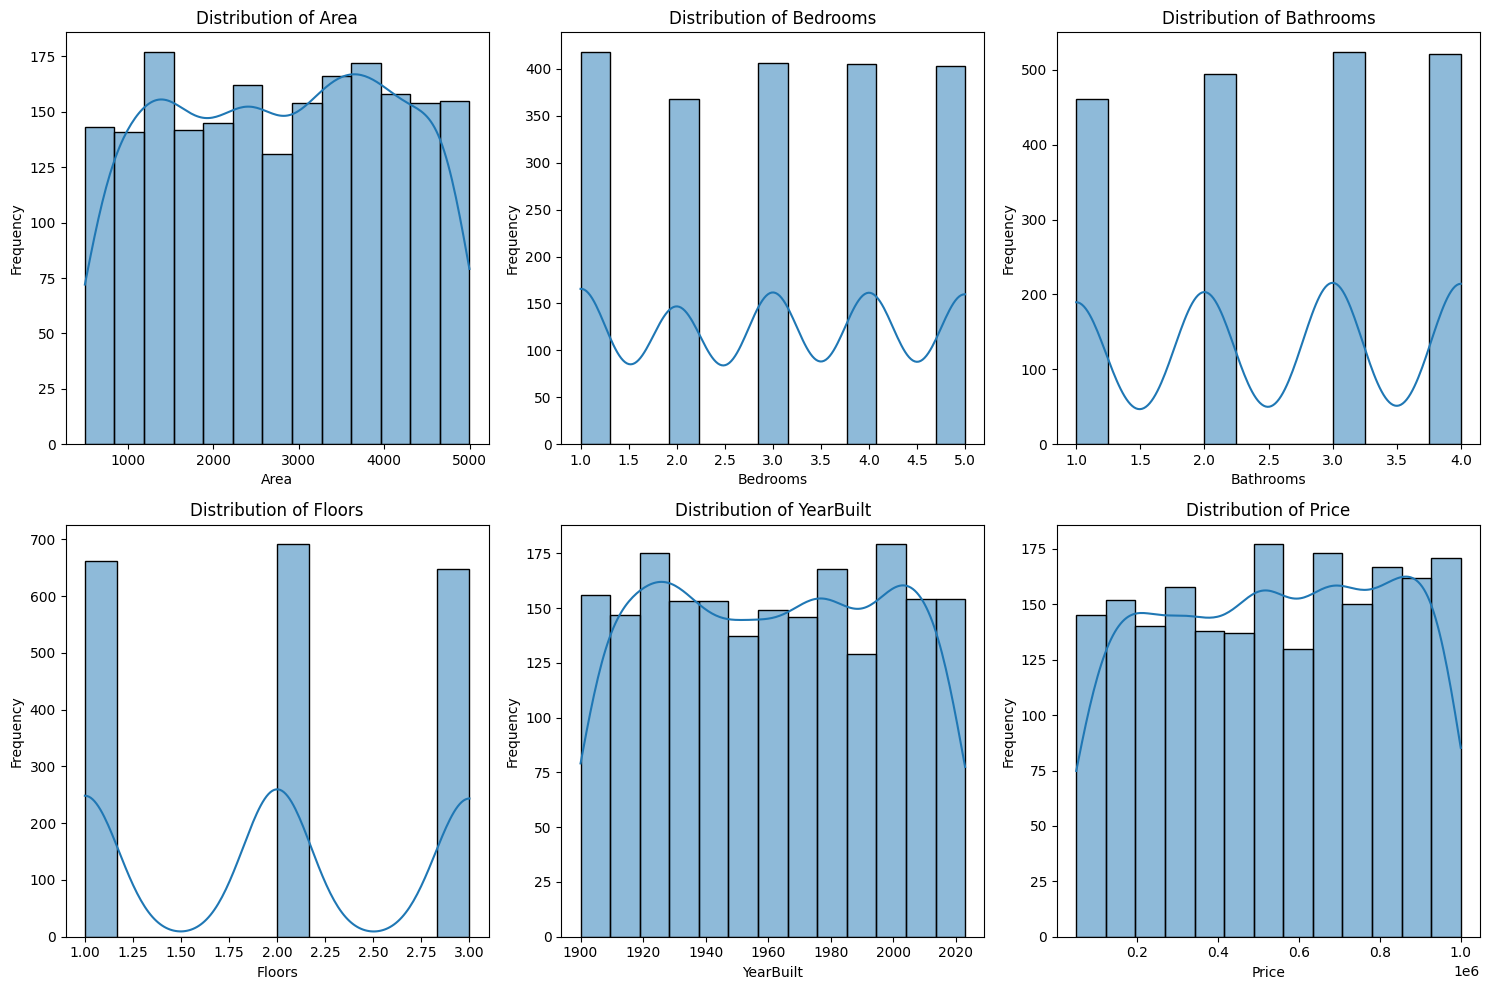

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns for histograms
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

# Plotting histograms for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the frequency of each category for the categorical features, I will generate count plots using `seaborn` for 'Location', 'Condition', and 'Garage'. This will help understand the distribution of values within these columns.



/tmp/ipython-input-7-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-7-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-7-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


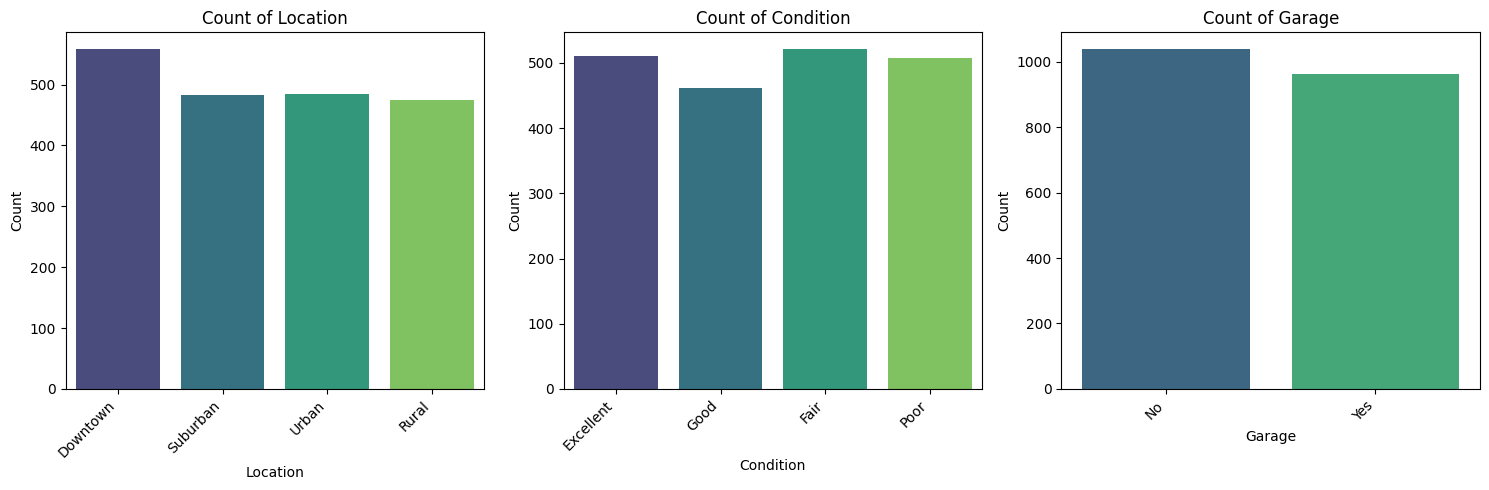

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for count plots
categorical_cols = ['Location', 'Condition', 'Garage']

# Plotting count plots for categorical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning about using `palette` without `hue` in `sns.countplot`. To address this, I will modify the `countplot` call to explicitly assign the `x` variable to `hue` and set `legend=False`, as suggested by the warning, to ensure compatibility with future Seaborn versions.



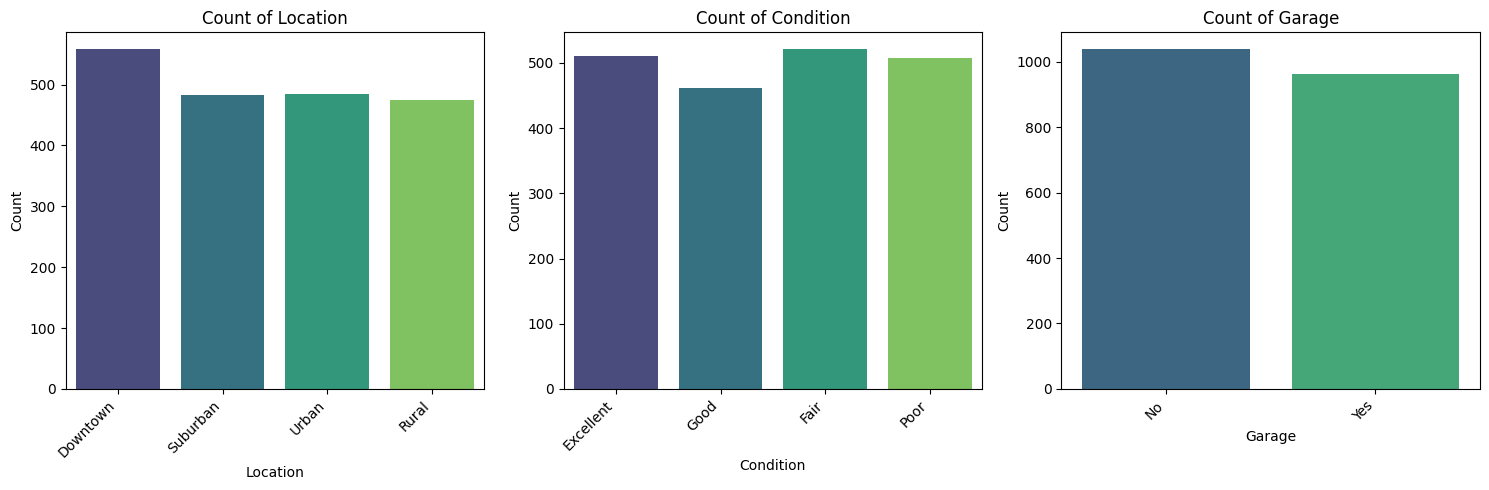

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for count plots
categorical_cols = ['Location', 'Condition', 'Garage']

# Plotting count plots for categorical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To examine the relationship between numerical features and the 'Price' column, I will generate scatter plots for 'Area' vs 'Price' and 'YearBuilt' vs 'Price' using `seaborn.scatterplot`.



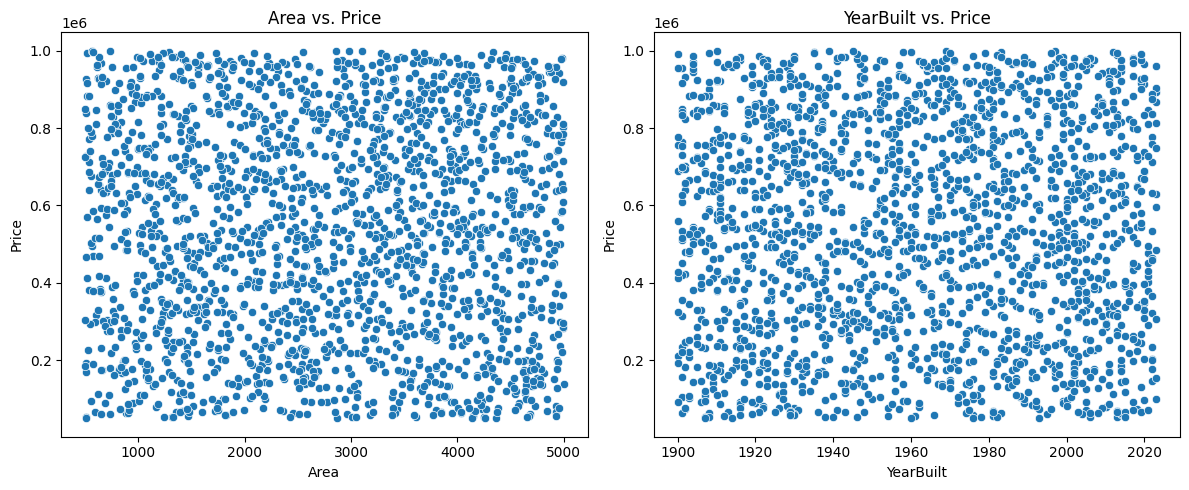

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns for scatter plots against Price
scatter_cols = ['Area', 'YearBuilt']

plt.figure(figsize=(12, 5))
for i, col in enumerate(scatter_cols):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'{col} vs. Price')
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the relationship between categorical features and the 'Price' column, I will generate box plots for 'Location', 'Condition', and 'Garage' against 'Price' using `seaborn.boxplot`.



/tmp/ipython-input-10-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
/tmp/ipython-input-10-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
/tmp/ipython-input-10-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')


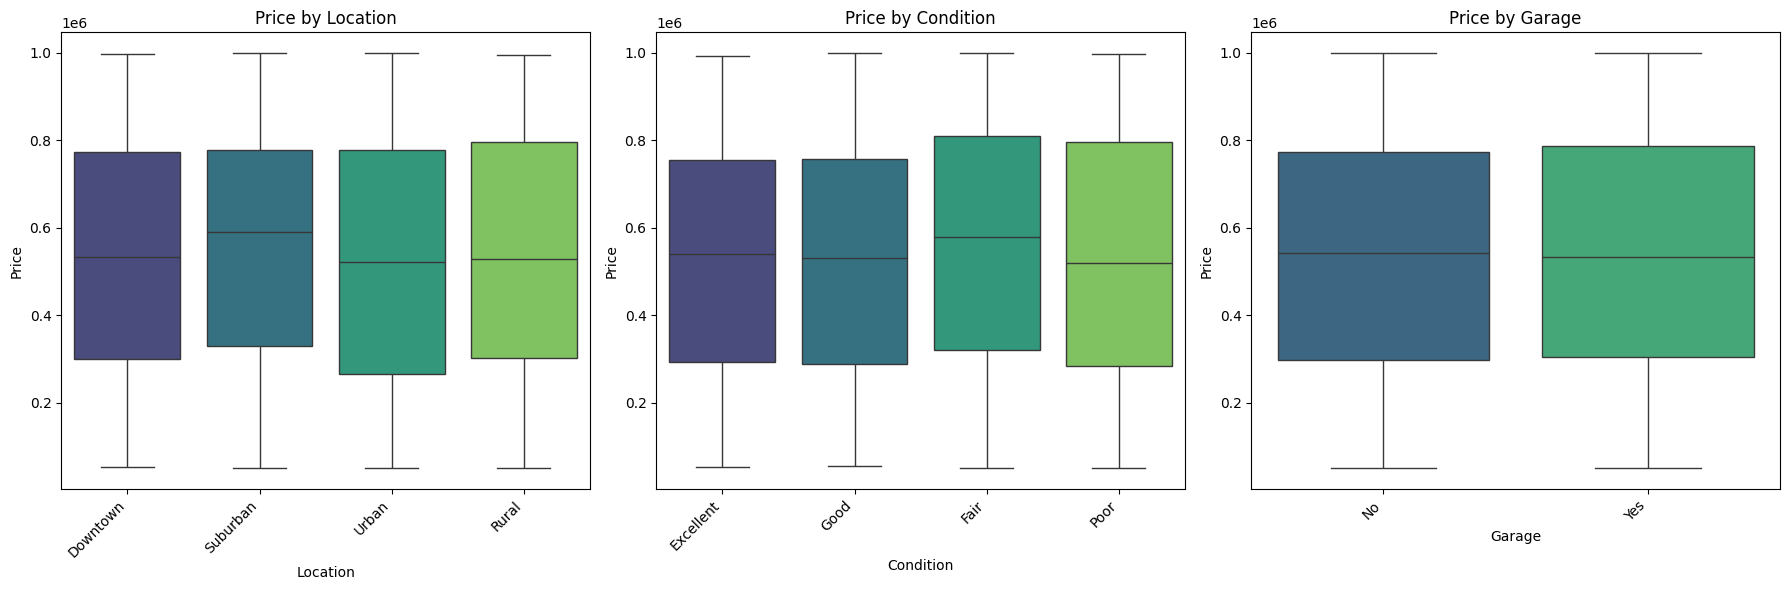

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for box plots against Price
categorical_cols = ['Location', 'Condition', 'Garage']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning about using `palette` without `hue` in `sns.boxplot`. To address this, I will modify the `boxplot` call to explicitly assign the `x` variable to `hue` and set `legend=False`, as suggested by the warning, to ensure compatibility with future Seaborn versions.



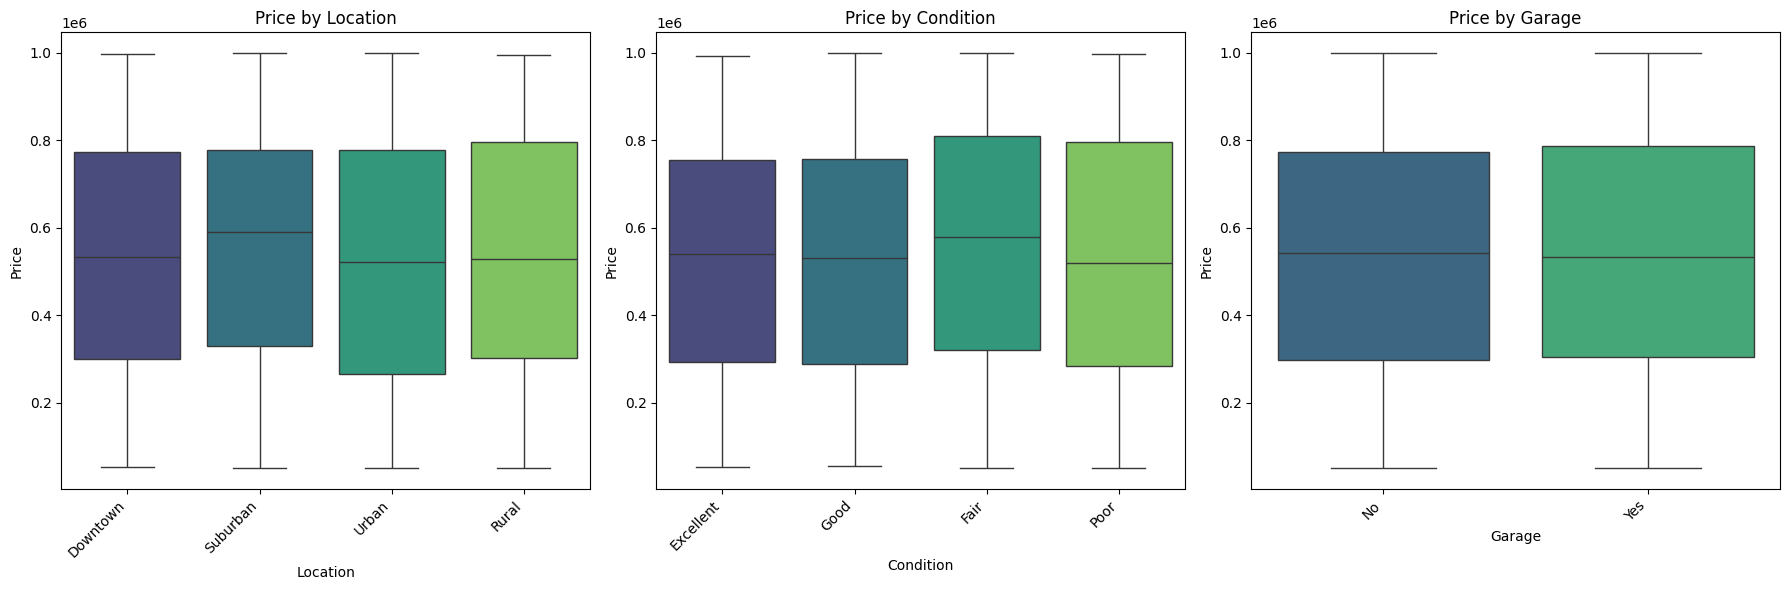

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for box plots against Price
categorical_cols = ['Location', 'Condition', 'Garage']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Matrix

**Reasoning**:
To understand the linear relationships between all numerical features, including the target variable 'Price', I will compute the correlation matrix and visualize it using a heatmap. This helps identify strongly correlated features, which can be useful for feature selection and model building.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


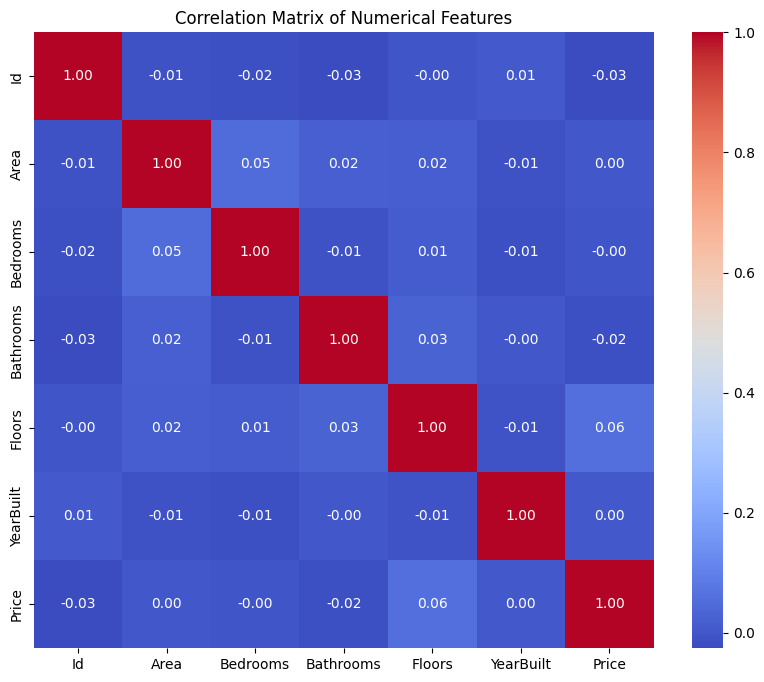

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Identify and Drop Unnecessary Columns

### Subtask:
Based on the EDA and the objective of house price prediction, identify and remove columns that are deemed irrelevant, redundant, or would not contribute positively to the prediction model.


**Reasoning**:
Based on the initial inspection, the 'Id' column appears to be a unique identifier and does not contribute to house price prediction, therefore, I will remove it from the DataFrame.



In [14]:
print("Columns before dropping 'Id':", df.columns.tolist())
df.drop('Id', axis=1, inplace=True)
print("Columns after dropping 'Id':", df.columns.tolist())

print("\nFirst 5 rows of the DataFrame after dropping 'Id' column:")
print(df.head())

print("\nDataFrame Info after dropping 'Id' column:")
df.info()

Columns before dropping 'Id': ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']
Columns after dropping 'Id': ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

First 5 rows of the DataFrame after dropping 'Id' column:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage  \
0  1360         5          4       3       1970  Downtown  Excellent     No   
1  4272         5          4       3       1958  Downtown  Excellent     No   
2  3592         2          2       3       1938  Downtown       Good     No   
3   966         4          2       2       1902  Suburban       Fair    Yes   
4  4926         1          4       2       1975  Downtown       Fair    Yes   

    Price  
0  149919  
1  424998  
2  266746  
3  244020  
4  636056  

DataFrame Info after dropping 'Id' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data colu

# Task
Develop and compare machine learning models for house price prediction using the "House_Price_Prediction_Dataset.csv" dataset. This involves preparing the data for modeling, training and evaluating Linear Regression and Random Forest Regressor models, visualizing their predictions and performance, and finally, summarizing and identifying the best-performing model.

## Prepare Data for Modeling

### Subtask:
One-hot encode categorical features and split the dataset into training and testing sets. This prepares the data for machine learning models.


**Reasoning**:
To prepare the data for modeling, I will first identify the categorical columns, apply one-hot encoding to them, and then separate the features (X) and target (y) variables. Finally, I will split the dataset into training and testing sets using `train_test_split`.



In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {categorical_cols.tolist()}")

# 2. Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nDataFrame after one-hot encoding (first 5 rows):")
print(df_encoded.head())

# 3. Define features (X) and target (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 4 & 5. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Categorical columns identified: ['Location', 'Condition', 'Garage']

DataFrame after one-hot encoding (first 5 rows):
   Area  Bedrooms  Bathrooms  Floors  YearBuilt   Price  Location_Rural  \
0  1360         5          4       3       1970  149919           False   
1  4272         5          4       3       1958  424998           False   
2  3592         2          2       3       1938  266746           False   
3   966         4          2       2       1902  244020           False   
4  4926         1          4       2       1975  636056           False   

   Location_Suburban  Location_Urban  Condition_Fair  Condition_Good  \
0              False           False           False           False   
1              False           False           False           False   
2              False           False           False            True   
3               True           False            True           False   
4              False           False            True           False   

## Train and Evaluate Linear Regression Model

### Subtask:
Train a Linear Regression model on the preprocessed training data, make predictions on the test set, and evaluate its performance using metrics like R-squared and Mean Absolute Error.


**Reasoning**:
To implement the Linear Regression model, I will import the necessary classes and functions from `sklearn`, instantiate the model, train it with the training data, make predictions on the test data, and then evaluate its performance using R-squared and Mean Absolute Error.



In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Calculate R-squared and Mean Absolute Error
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Print the evaluation metrics
print(f"Linear Regression R-squared: {r2_lr:.4f}")
print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.2f}")

Linear Regression R-squared: -0.0067
Linear Regression Mean Absolute Error (MAE): 243241.98


## Train and Evaluate Random Forest Regressor Model

### Subtask:
Train a Random Forest Regressor model, make predictions on the test set, and evaluate its performance using relevant regression metrics.


**Reasoning**:
To implement the Random Forest Regressor model, I will import the necessary classes and functions from `sklearn`, instantiate the model, train it with the training data, make predictions on the test data, and then evaluate its performance using R-squared and Mean Absolute Error.



In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Instantiate the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Calculate R-squared and Mean Absolute Error
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Regressor R-squared: {r2_rf:.4f}")
print(f"Random Forest Regressor Mean Absolute Error (MAE): {mae_rf:.2f}")

Random Forest Regressor R-squared: -0.0964
Random Forest Regressor Mean Absolute Error (MAE): 252518.03


## Visualize Model Predictions and Performance

### Subtask:
Create scatter plots to visualize the actual vs. predicted prices for each model and a bar chart to compare their R-squared scores, providing a visual comparison of model performance.


**Reasoning**:
To visualize the actual vs. predicted prices for both Linear Regression and Random Forest models, I will create two scatter plots side-by-side. Additionally, to compare their performance, I will generate a bar chart showing their respective R-squared scores.



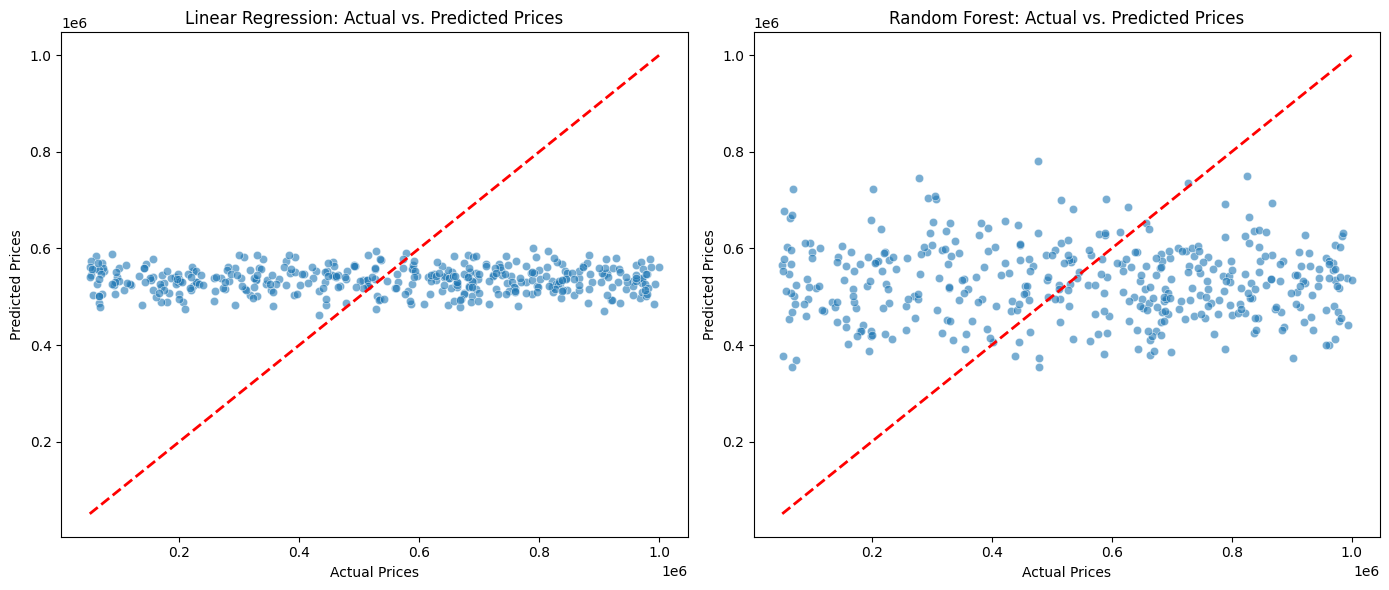

/tmp/ipython-input-18-607083211.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='viridis')


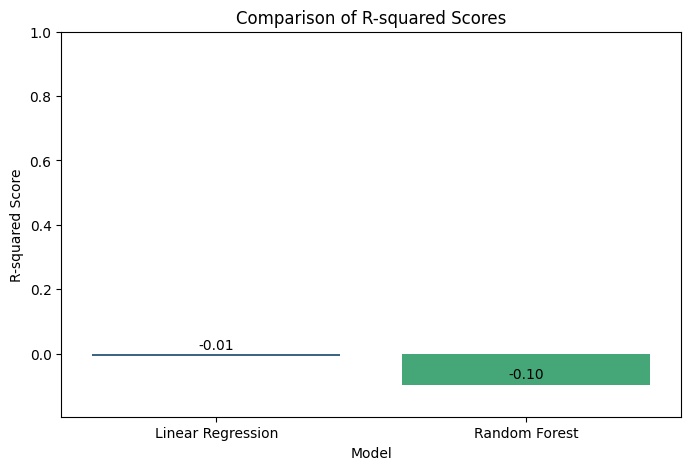

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Scatter plots for actual vs. predicted prices
plt.figure(figsize=(14, 6))

# Linear Regression scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# Random Forest scatter plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.tight_layout()
plt.show()

# 2. Bar chart for R-squared scores comparison
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=r2_scores, palette='viridis')
plt.title('Comparison of R-squared Scores')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.ylim(min(0, min(r2_scores) - 0.1), max(1, max(r2_scores) + 0.1)) # Adjust y-axis limits dynamically
for index, value in enumerate(r2_scores):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` about using `palette` without `hue` in `sns.barplot`. To address this, I will modify the `barplot` call to explicitly assign the `x` variable (`models`) to `hue` and set `legend=False`, as suggested by the warning, to ensure compatibility with future Seaborn versions.



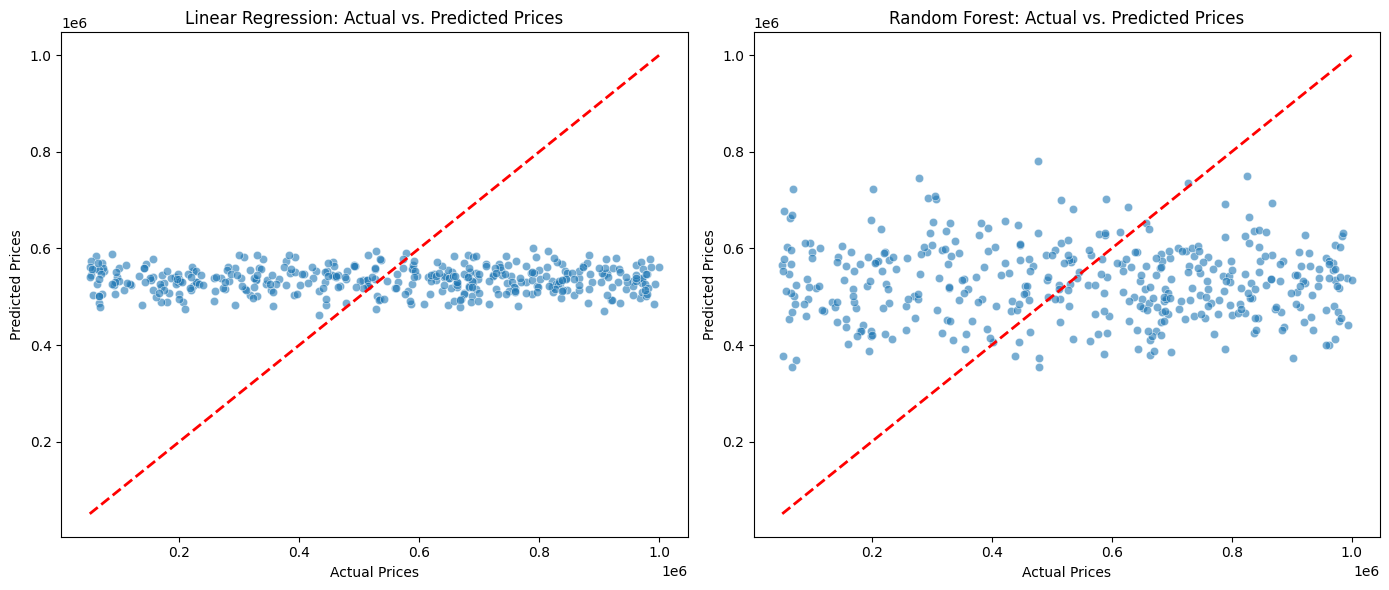

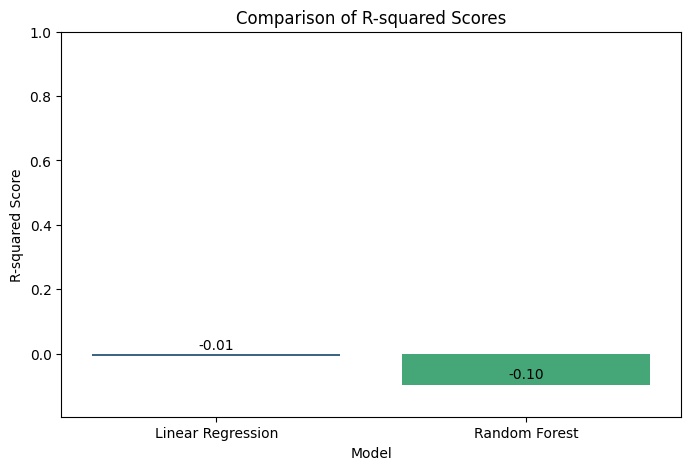

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Scatter plots for actual vs. predicted prices
plt.figure(figsize=(14, 6))

# Linear Regression scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# Random Forest scatter plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.tight_layout()
plt.show()

# 2. Bar chart for R-squared scores comparison
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=r2_scores, hue=models, palette='viridis', legend=False)
plt.title('Comparison of R-squared Scores')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.ylim(min(0, min(r2_scores) - 0.1), max(1, max(r2_scores) + 0.1)) # Adjust y-axis limits dynamically
for index, value in enumerate(r2_scores):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.show()

## Final Task

### Subtask:
Summarize the performance of the evaluated algorithms and identify the best-performing model based on the chosen metrics and visualizations.


## Summary:

### Q&A
The evaluated models, Linear Regression and Random Forest Regressor, both exhibited very poor performance in predicting house prices. Neither model effectively captured the underlying patterns in the data, as indicated by their negative R-squared scores. Based on the chosen metrics, the Linear Regression model performed marginally better, with a less negative R-squared score.

### Data Analysis Key Findings
*   **Data Preparation:** Categorical features (`Location`, `Condition`, `Garage`) were successfully one-hot encoded, and the dataset was split into training (1600 samples) and testing (400 samples) sets. The feature matrix `X` had 12 columns after encoding.
*   **Linear Regression Performance:** The Linear Regression model yielded an R-squared score of -0.0067 and a Mean Absolute Error (MAE) of \$243,241.98. The negative R-squared indicates that the model performs worse than a simple horizontal line (predicting the mean).
*   **Random Forest Regressor Performance:** The Random Forest Regressor model resulted in an R-squared score of -0.0964 and an MAE of \$252,518.03. This model performed even worse than Linear Regression, further confirming its inability to explain the variance in house prices.
*   **Comparative Performance:** Both models failed to explain any variance in house prices, as evidenced by their negative R-squared values. Linear Regression, despite its poor performance, was marginally better than Random Forest in terms of R-squared ($-0.0067$ vs. $-0.0964$).
*   **Visualizations:** Scatter plots of actual vs. predicted prices for both models showed widely dispersed points, with no clear linear relationship, visually confirming the poor fit of the models.

### Insights or Next Steps
*   The current models (Linear Regression and Random Forest Regressor with default parameters) are unsuitable for accurate house price prediction on this dataset.
*   Further investigation is needed, including advanced feature engineering, exploring different machine learning models (e.g., Gradient Boosting, Neural Networks), and hyperparameter tuning to improve predictive performance.
